# EPInformer-seq Testing: per-cell DNase + H3K27ac activity at the SORT1 locus

`EPInformer-seq` is a per-cell sequence encoder that takes a **2114-bp** DNA
window, runs it through a dilated CNN body, and crops the **central 1024 bp**
for its heads (ChromBPNet-style "valid" geometry — every output base has a full
real-sequence receptive field). It is a **2-channel** model: **ch0 = DNase**
(5′ cut-sites, motif-sensitive) and **ch1 = H3K27ac** (the active-enhancer histone mark). Chorus
ships per-cell weights for 11 Roadmap cell lines (K562, GM12878, HepG2, A549,
HeLa, HMEC, HSMM, HUVEC, NHEK, NHLF, H1).

A per-cell frozen **BiasNet** (ChromBPNet-style, 2-channel, 1024-bp) subtracts
Tn5/MNase sequence bias on the central 1024-bp crop; channel 1 carries the
H3K27ac background bias. It returns one scalar per region — the linear peak
signal over the central 256 bp — under one of three assays:

- **`Enhancer_DNase`** (default): max DNase.
- **`Enhancer_H3K27ac`**: max H3K27ac.
- **`Enhancer_H3K27ac_DNase`**: composite `sqrt(max DNase × max H3K27ac)`.

> **Reading the three assays.** **DNase** = chromatin *accessibility*; **H3K27ac** = enhancer *activity* (the active-enhancer histone mark); **composite** = `sqrt(DNase × H3K27ac)`, a combined accessibility-and-activity score that weights both. They can disagree for a variant — a region can be accessible but not active, or vice-versa — so the three are shown side-by-side rather than collapsed to one number. As a rule of thumb: DNase moves with motif disruption/creation, H3K27ac with enhancer activation, and the composite when both shift together.

Per-cell held-out test-`r`: DNase 0.59–0.88, H3K27ac 0.48–0.67.

This notebook is the end-to-end smoke test for the oracle. It walks the
[rs12740374](https://www.ncbi.nlm.nih.gov/snp/rs12740374) locus on chr1 —
the canonical SORT1/CELSR2 GWAS variant that creates a new C/EBP-α binding
site and turns a quiescent hepatocyte enhancer into an active one — and
exercises every feature of the oracle:

1. Instantiate + load default checkpoint (K562).
2. Wild-type prediction on genomic coordinates.
3. Variant-effect prediction (ref vs. alt).
4. Cross-cell discovery — loop over all 11 cells without re-instantiating.
5. Saturation mutagenesis (ISM) over the central scanned window.
6. Cross-oracle comparison vs. ChromBPNet DNase (and optionally AlphaGenome).

**Runtime**: ~5–10 min on Apple Silicon (MPS) or NVIDIA (CUDA).
**Prereqs**: `chorus setup --oracle epinformerseq` + per-cell weights
(auto-fetched from the HF mirror `lucapinello/chorus-epinformerseq-v2`,
`per_cell_widewin/`) + background CDFs at
`~/.chorus/backgrounds/epinformerseq_pertrack.npz` (33 tracks: 3 assays × 11
cells), built by `scripts/build_backgrounds_epinformerseq_v2_percell.py`.

> Most cells below demonstrate the default `Enhancer_DNase` assay; swap
> `ASSAY` (cell 2) to `Enhancer_H3K27ac` or `Enhancer_H3K27ac_DNase` to score
> the other channels.


## Setup

In [1]:
import os
# Allow conda-env subprocess imports (env validation runs `python -c "import torch"`
# inside chorus-epinformerseq; libomp.dylib gets loaded from both envs on macOS
# and would otherwise abort with `OMP: Error #15`). This is the canonical
# macOS workaround and is safe for inference-only workloads.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import warnings
warnings.filterwarnings(
    'ignore',
    message=".*padding='same'.*",
)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import chorus
from chorus.utils import get_genome, extract_sequence
from chorus.analysis.normalization import PerTrackNormalizer
from chorus.oracles.epinformerseq_source.globals import (
    EPINFORMERSEQ_AVAILABLE_CELLTYPES,
)

# Default assay. Swap to 'Enhancer_H3K27ac' or 'Enhancer_H3K27ac_DNase' (composite)
# to score the other channels of the 2-channel model.
ASSAY = 'Enhancer_DNase'
print('chorus version:', chorus.__version__)
print('assay        :', ASSAY)


chorus version: 0.5.6
assay        : Enhancer_DNase


In [2]:
# Reference genome (auto-downloads to ~/.chorus/genomes if missing).
genome_path = get_genome('hg38')
print('genome:', genome_path)


genome: /Users/jieconglin/Documents/hpc-projects/chorus/genomes/hg38.fa


## 1. Create the EPInformer-seq oracle

We load the default `K562` checkpoint first. `use_environment=True` runs
the model inside the `chorus-epinformerseq` conda env (PyTorch + a few
bio utilities) — chorus spawns and manages the subprocess for us.


In [3]:
oracle = chorus.create_oracle(
    'epinformerseq',
    use_environment=True,
    cell_type='K562',
    reference_fasta=str(genome_path),
)
oracle.load_pretrained_model()

print('loaded =', oracle.loaded)
print('assay_id =', oracle.assay_id)
print('window =', oracle.sequence_length, 'bp')
print('available cell types =', EPINFORMERSEQ_AVAILABLE_CELLTYPES)
print('available assays =', oracle.list_assay_types())


2026-06-04 14:53:42,277 - chorus.core.base - INFO - CHORUS_NO_TIMEOUT is set - all timeouts disabled


2026-06-04 14:53:42,277 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-06-04 14:53:44,043 - chorus.core.base - INFO - Using conda environment: chorus-epinformerseq


2026-06-04 14:53:47,602 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


loaded = True
assay_id = Enhancer_DNase:K562
window = 2114 bp
available cell types = ['K562', 'GM12878', 'HepG2', 'A549', 'HeLa', 'HMEC', 'HSMM', 'HUVEC', 'NHEK', 'NHLF', 'H1']
available assays = ['Enhancer_DNase', 'Enhancer_H3K27ac', 'Enhancer_H3K27ac_DNase']


## 2. Wild-type activity at the SORT1 enhancer

We score a 2114-bp window centred on rs12740374 (chr1:109,274,968 in hg38,
1-based). The variant sits at the dead centre of the model's input; the heads
see the central 1024 bp. The returned scalar is the **linear max-DNase** signal
over the central 256 bp in RPM-space (not log₂); we look it up against the
precomputed genome-wide baseline CDF.

In [4]:
VARIANT_POS = 109_274_968  # 1-based, hg38
HALF = 1057                # 2114-bp model input window, centred on the variant
REGION_START = VARIANT_POS - HALF + 1   # 1-based inclusive
REGION_END   = VARIANT_POS + HALF       # 1-based inclusive
TRACK_K562 = f'{ASSAY}:K562'            # Enhancer_DNase:K562
print(f'region = chr1:{REGION_START}-{REGION_END}  ({REGION_END-REGION_START+1} bp)')
print(f'track  = {TRACK_K562}')

wt_pred = oracle.predict(
    ('chr1', REGION_START, REGION_END),
    [TRACK_K562],
)
wt_track = wt_pred[TRACK_K562]

wt_value = float(wt_track.values[0])
print(f'WT max-DNase [K562] = {wt_value:.4f}  (linear RPM, central 256 bp)')


region = chr1:109273912-109276025  (2114 bp)
track  = Enhancer_DNase:K562


WT max-DNase [K562] = 12.4603  (linear RPM, central 256 bp)


In [5]:
# Convert to an activity %ile against the per-track CDF built from
# ~30k cCRE + TSS + random hg38 positions.
norm = PerTrackNormalizer()
assert norm.has_oracle('epinformerseq'), \
    'epinformerseq backgrounds not installed; run scripts/build_backgrounds_epinformerseq.py'

act_pct = norm.activity_percentile('epinformerseq', TRACK_K562, wt_value)
print(f'WT activity %ile (K562) = {act_pct:.3f}')
print(f'  ({100*act_pct:.1f} %% of background positions show LOWER activity)')


2026-06-04 14:53:50,950 - chorus.analysis.normalization - INFO - Loaded per-track CDFs for 'epinformerseq': 33 tracks, CDFs: effect_cdfs, summary_cdfs


WT activity %ile (K562) = 0.866
  (86.6 %% of background positions show LOWER activity)


## 3. Variant effect — rs12740374 G>T

`predict_variant_effect` returns predictions for the reference and each
alternate allele. The `Enhancer_DNase` layer is **signed**:
effect = ALT − REF, in linear max-DNase units.

In [6]:
ve = oracle.predict_variant_effect(
    genomic_region=f'chr1:{REGION_START}-{REGION_END}',
    variant_position=f'chr1:{VARIANT_POS}',
    alleles=['G', 'T'],
    assay_ids=[TRACK_K562],
)
ref_val = float(ve['predictions']['reference'][TRACK_K562].values[0])
alt_val = float(ve['predictions']['alt_1'][TRACK_K562].values[0])
effect  = alt_val - ref_val
eff_pct = norm.effect_percentile('epinformerseq', TRACK_K562, effect)

pd.DataFrame([{
    'oracle': 'epinformerseq',
    'track': TRACK_K562,
    'ref_value': ref_val,
    'alt_value': alt_val,
    'signed_effect_linear': effect,
    'fold_change_alt_over_ref': alt_val / ref_val,
    'effect_pctile': eff_pct,
}])


,oracle,track,ref_value,alt_value,signed_effect_linear,fold_change_alt_over_ref,effect_pctile
0,epinformerseq,Enhancer_DNase:K562,12.449542,14.642244,2.192702,1.176127,1.0


> **Interpretation.** rs12740374 G→T is the SORT1 GWAS-LDL variant. The
> ALT allele creates a C/EBP-α binding site that opens chromatin in
> hepatocytes. K562 is *not* a hepatocyte line — we expect a small
> positive effect but the relevant signal will show up much more
> strongly in HepG2 (§4).


## 4. Cross-cell discovery across all 11 Roadmap cells

This exercises `oracle.load_pretrained_model(cell_type=...)` — switching the
model to a different cell's checkpoint without re-instantiating the oracle. For
each of the 11 cells we predict the ref / alt max-DNase activity at the same
variant and tally the signed effect (linear) and `log2fc`.

In [7]:
rows = []
for ct in EPINFORMERSEQ_AVAILABLE_CELLTYPES:
    oracle.load_pretrained_model(cell_type=ct)
    tid = f'{ASSAY}:{ct}'          # Enhancer_DNase:{ct}
    oracle.assay_id = tid          # match the cell we just loaded
    res = oracle.predict_variant_effect(
        genomic_region=f'chr1:{REGION_START}-{REGION_END}',
        variant_position=f'chr1:{VARIANT_POS}',
        alleles=['G', 'T'],
        assay_ids=[tid],
    )
    r = float(res['predictions']['reference'][tid].values[0])
    a = float(res['predictions']['alt_1'][tid].values[0])
    rows.append({
        'cell_type':    ct,
        'ref_dnase':    r,
        'alt_dnase':    a,
        'effect_dnase': a - r,
        'log2fc_dnase': float(np.log2((a + 1.0) / (r + 1.0))),
    })

df = pd.DataFrame(rows).set_index('cell_type')
df.sort_values('effect_dnase', ascending=False).style.format({
    c: ('{:+.3f}' if c.startswith(('effect', 'log2fc')) else '{:.3f}')
    for c in df.columns
})

2026-06-04 14:54:01,093 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-06-04 14:54:10,685 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-06-04 14:54:20,419 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-06-04 14:54:30,154 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-06-04 14:54:39,709 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


...

2026-06-04 14:55:08,460 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-06-04 14:55:18,056 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-06-04 14:55:27,681 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-06-04 14:55:37,297 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


,ref_dnase,alt_dnase,effect_dnase,log2fc_dnase
cell_type,,,,
HSMM,13.492,78.904,+65.412,+2.463
NHLF,17.327,37.982,+20.654,+1.089
HepG2,22.479,35.221,+12.742,+0.625
K562,12.450,14.642,+2.193,+0.218
HeLa,2.873,4.802,+1.929,+0.583
A549,1.363,2.190,+0.828,+0.433
H1,10.041,10.666,+0.625,+0.079
GM12878,2.731,3.046,+0.315,+0.117
HMEC,3.165,3.376,+0.212,+0.071


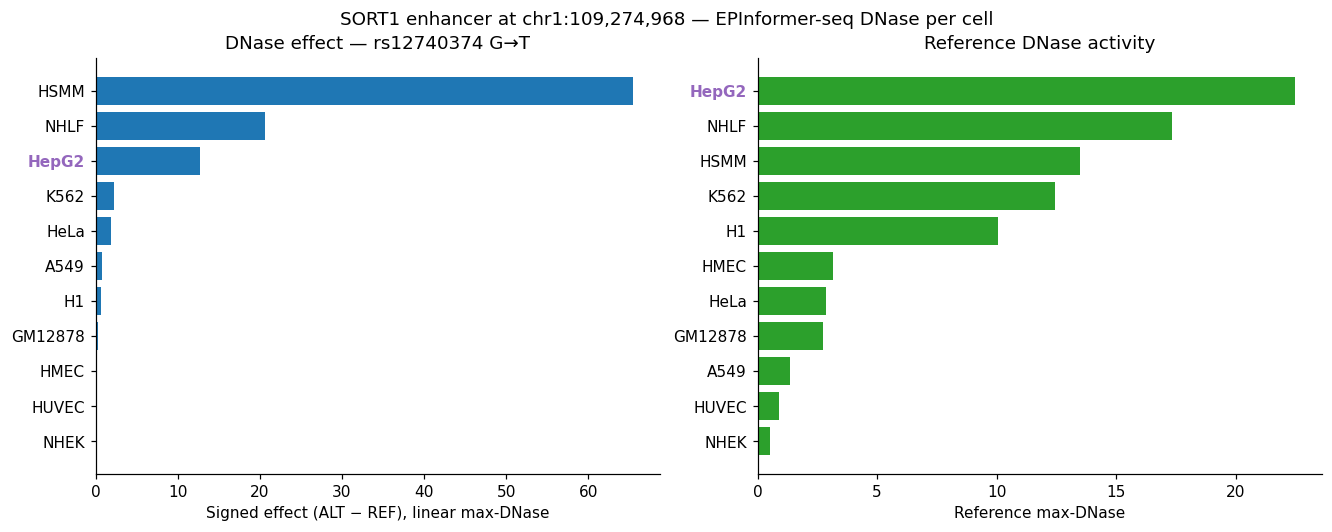

In [8]:
# Two panels: signed DNase effect (left) and reference DNase activity (right).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

def _barh(ax, values, title, xlabel, color_pos='#1f77b4', color_neg='#d62728'):
    order = values.sort_values().index
    colors = [color_neg if v < 0 else color_pos for v in values.loc[order]]
    ax.barh(order, values.loc[order], color=colors)
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    for tick in ax.get_yticklabels():
        if tick.get_text() == 'HepG2':
            tick.set_fontweight('bold')
            tick.set_color('#9467bd')

_barh(axes[0], df['effect_dnase'],
      'DNase effect — rs12740374 G→T',
      'Signed effect (ALT − REF), linear max-DNase')
_barh(axes[1], df['ref_dnase'],
      'Reference DNase activity',
      'Reference max-DNase',
      color_pos='#2ca02c')

fig.suptitle('SORT1 enhancer at chr1:109,274,968 — EPInformer-seq DNase per cell',
             y=1.04, fontsize=12)
plt.show()

## § 4.5 Cross-oracle DNase comparison — EPInformer-seq vs ChromBPNet vs AlphaGenome

EPInformer-seq scores 5′ DNase cut-sites at TF-footprint scale. This section
runs the same variant through two other DNase specialists for a side-by-side
comparison on the 4 cells where all three oracles share a clear DNase track:
**K562, GM12878, HepG2, A549**.

- **ChromBPNet (per-cell DNase)** — per-bp cut-site counts at TF-footprint
  resolution; expected to show a clean cell-specific signature at the
  rs12740374 CEBPA motif (HepG2 dominant).
- **AlphaGenome (DNase tracks)** — long-range, multi-tissue. Looks up the
  matching cell/tissue DNase track per cell.

Effects are reported as `log2((alt + 1) / (ref + 1))` so the magnitudes are
directly comparable across oracles (each one's native scale differs).

In [9]:
# ChromBPNet DNase per cell — central-256-bp max signal as the scalar to compare.
import numpy as np
CROSS_CELLS = ['K562', 'GM12878', 'HepG2', 'A549']
cross_rows = []

# (a) EPI-seq DNase effect — already in df from § 4.
for ct in CROSS_CELLS:
    r = df.loc[ct, 'ref_dnase']
    a = df.loc[ct, 'alt_dnase']
    cross_rows.append({'oracle': 'epinformerseq', 'cell': ct,
                       'ref': r, 'alt': a,
                       'log2fc': float(np.log2((a + 1.0) / (r + 1.0)))})

# (b) ChromBPNet DNase per cell.
cbp = chorus.create_oracle('chrombpnet', use_environment=True,
                           reference_fasta=str(genome_path))
for ct in CROSS_CELLS:
    try:
        cbp.load_pretrained_model(assay='DNASE', cell_type=ct, fold=0)
        ve = cbp.predict_variant_effect(
            genomic_region=f'chr1:{VARIANT_POS - 1057}-{VARIANT_POS + 1057}',
            variant_position=f'chr1:{VARIANT_POS}',
            alleles=['G', 'T'],
            assay_ids=None,
        )
        ref_pred = ve['predictions']['reference']
        alt_pred = ve['predictions']['alt_1']
        # Pick the bias-corrected DNase track (one per call); aggregate the
        # central 256 bp as max signal to match EPI-seq's scalar convention.
        for tid, ref_track in ref_pred.items():
            ref_vals = np.asarray(ref_track.values, dtype=np.float32)
            alt_vals = np.asarray(alt_pred[tid].values, dtype=np.float32)
            mid = len(ref_vals) // 2
            half = 128
            ref_max = float(ref_vals[mid - half:mid + half].max())
            alt_max = float(alt_vals[mid - half:mid + half].max())
            cross_rows.append({'oracle': 'chrombpnet', 'cell': ct,
                               'ref': ref_max, 'alt': alt_max,
                               'log2fc': float(np.log2((alt_max + 1.0) / (ref_max + 1.0)))})
            print(f'  ChromBPNet {ct} {tid}: ref={ref_max:.3f} alt={alt_max:.3f} '
                  f'log2fc={cross_rows[-1]["log2fc"]:+.3f}')
            break  # one (bias-corrected) track per cell
    except Exception as exc:
        print(f'  ChromBPNet {ct} skipped: {type(exc).__name__}: {exc}')

cross_cbp = pd.DataFrame(cross_rows)
cross_cbp[cross_cbp['oracle'].isin(['epinformerseq', 'chrombpnet'])]

2026-06-04 14:55:43,953 - chorus.core.base - INFO - CHORUS_NO_TIMEOUT is set - all timeouts disabled


2026-06-04 14:55:43,953 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-06-04 14:55:47,573 - chorus.core.base - INFO - Using conda environment: chorus-chrombpnet


2026-06-04 14:55:52,491 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/manifest.json "HTTP/1.1 307 Temporary Redirect"


2026-06-04 14:55:52,683 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/lucapinello/chorus-chrombpnet-slim/9fe92856bd189042207a8696f96758c53ea5cdd6/manifest.json "HTTP/1.1 200 OK"


...

2026-06-04 14:56:21,349 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-06-04 14:56:25,323 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


  ChromBPNet HepG2 DNASE:HepG2: ref=1.987 alt=7.017 log2fc=+1.424
  ChromBPNet A549 skipped: InvalidAssayError: ChromBPNet DNASE predictions can only be done on the following cell types: ['HepG2', 'IMR-90', 'GM12878', 'K562', 'H1', 'forelimb_bud', 'hindlimb_bud', 'forebrain', 'liver', 'limb', 'neural_tube', 'embryonic_facial_prominence', 'midbrain', 'hindbrain', 'limb_E11.5', 'limb_E14.5', 'liver_E11.5', 'liver_E14.5', 'forebrain_E11.5', 'forebrain_E14.5', 'midbrain_E11.5', 'midbrain_E14.5', 'hindbrain_E11.5', 'hindbrain_E14.5', 'embryonic_facial_prominence_E11.5', 'embryonic_facial_prominence_E14.5', 'neural_tube_E11.5'].


,oracle,cell,ref,alt,log2fc
0,epinformerseq,K562,12.449542,14.642244,0.217890
1,epinformerseq,GM12878,2.731171,3.045838,0.116810
2,epinformerseq,HepG2,22.479200,35.221252,0.625453
3,epinformerseq,A549,1.362733,2.190492,0.433322
4,chrombpnet,K562,0.771906,0.989719,0.167262
5,chrombpnet,GM12878,0.265662,0.326081,0.067277
6,chrombpnet,HepG2,1.987288,7.017320,1.424284


In [10]:
# AlphaGenome DNase per cell — exact track IDs (EFO ontology codes per cell line).
# Resolved once via ag.get_all_assay_ids() + alphagenome_tracks.json metadata.
CELL_TO_AG_TRACK = {
    'K562':    'DNASE/EFO:0002067 DNase-seq/.',
    'GM12878': 'DNASE/EFO:0002784 DNase-seq/.',
    'HepG2':   'DNASE/EFO:0001187 DNase-seq/.',
    'A549':    'DNASE/EFO:0001086 DNase-seq/.',
}
try:
    import os
    if os.environ.get('RUN_ALPHAGENOME') != '1':
        raise RuntimeError('AlphaGenome skipped — set RUN_ALPHAGENOME=1 (and HF auth) to enable')
    ag = chorus.create_oracle('alphagenome', use_environment=True,
                              reference_fasta=str(genome_path))
    ag.load_pretrained_model()
    available_dnase = {str(t) for t in ag.get_all_assay_ids() if str(t).startswith('DNASE/')}
    for ct, tid in CELL_TO_AG_TRACK.items():
        if tid not in available_dnase:
            print(f'  AlphaGenome {ct}: track {tid!r} not in catalog; skipping')
            continue
        try:
            ve = ag.predict_variant_effect(
                genomic_region=f'chr1:{VARIANT_POS - 100_000}-{VARIANT_POS + 100_000}',
                variant_position=f'chr1:{VARIANT_POS}',
                alleles=['G', 'T'],
                assay_ids=[tid],
            )
            ref_track = ve['predictions']['reference'][tid]
            alt_track = ve['predictions']['alt_1'][tid]
            ref_vals = np.asarray(ref_track.values, dtype=np.float32)
            alt_vals = np.asarray(alt_track.values, dtype=np.float32)
            mid = len(ref_vals) // 2
            half = 128  # central ~256 bp
            ref_max = float(ref_vals[mid - half:mid + half].max())
            alt_max = float(alt_vals[mid - half:mid + half].max())
            cross_rows.append({'oracle': 'alphagenome', 'cell': ct,
                               'ref': ref_max, 'alt': alt_max,
                               'log2fc': float(np.log2((alt_max + 1.0) / (ref_max + 1.0)))})
            print(f'  AlphaGenome {ct} ({tid}): ref={ref_max:.3f} alt={alt_max:.3f} '
                  f'log2fc={cross_rows[-1]["log2fc"]:+.3f}')
        except Exception as exc:
            print(f'  AlphaGenome {ct} ({tid}) failed: {type(exc).__name__}: {exc}')
except Exception as exc:
    print(f'AlphaGenome unavailable (HF auth / model load): {type(exc).__name__}: {exc}')

cross = pd.DataFrame(cross_rows)
cross

2026-06-04 14:56:33,777 - chorus.core.base - INFO - CHORUS_NO_TIMEOUT is set - all timeouts disabled


2026-06-04 14:56:33,778 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-06-04 14:56:35,008 - chorus.core.base - INFO - Using conda environment: chorus-alphagenome


2026-06-04 14:56:35,009 - chorus.oracles.alphagenome - INFO - Loading AlphaGenome model


2026-06-04 14:58:52,288 - chorus.oracles.alphagenome - INFO - AlphaGenome model loaded successfully in environment!


...

  AlphaGenome K562 (DNASE/EFO:0002067 DNase-seq/.): ref=5.312 alt=9.688 log2fc=+0.760


  AlphaGenome GM12878 (DNASE/EFO:0002784 DNase-seq/.): ref=1.234 alt=1.750 log2fc=+0.300


  AlphaGenome HepG2 (DNASE/EFO:0001187 DNase-seq/.): ref=9.312 alt=23.000 log2fc=+1.219


  AlphaGenome A549 (DNASE/EFO:0001086 DNase-seq/.): ref=1.719 alt=3.312 log2fc=+0.666


,oracle,cell,ref,alt,log2fc
0,epinformerseq,K562,12.449542,14.642244,0.217890
1,epinformerseq,GM12878,2.731171,3.045838,0.116810
2,epinformerseq,HepG2,22.479200,35.221252,0.625453
3,epinformerseq,A549,1.362733,2.190492,0.433322
4,chrombpnet,K562,0.771906,0.989719,0.167262
5,chrombpnet,GM12878,0.265662,0.326081,0.067277
6,chrombpnet,HepG2,1.987288,7.017320,1.424284
7,alphagenome,K562,5.312500,9.687500,0.759641
8,alphagenome,GM12878,1.234375,1.750000,0.299560
9,alphagenome,HepG2,9.312500,23.000000,1.218640


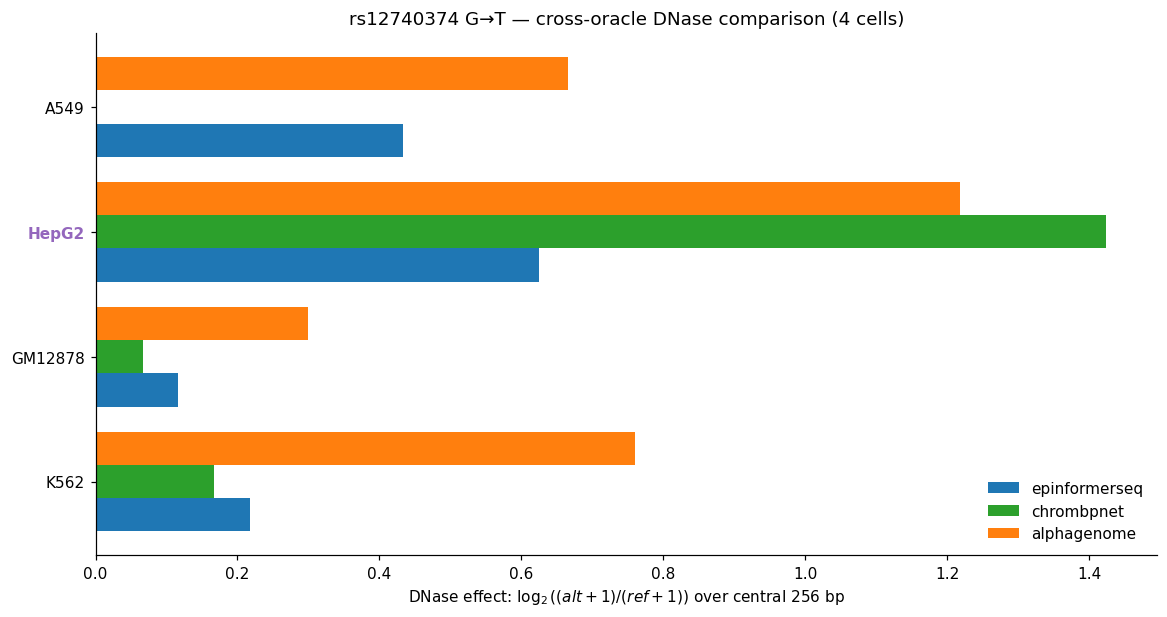

oracle,epinformerseq,chrombpnet,alphagenome
cell,,,
K562,0.218,0.167,0.760
GM12878,0.117,0.067,0.300
HepG2,0.625,1.424,1.219
A549,0.433,NaN,0.666


In [11]:
# Grouped bar chart: 4 cells × 3 oracles, log2fc DNase effect.
import numpy as np
ORACLE_ORDER = ['epinformerseq', 'chrombpnet', 'alphagenome']
ORACLE_COLOR = {'epinformerseq': '#1f77b4',
                'chrombpnet':    '#2ca02c',
                'alphagenome':   '#ff7f0e'}

pivot = (cross.pivot_table(index='cell', columns='oracle', values='log2fc',
                            aggfunc='first')
              .reindex(CROSS_CELLS)
              .reindex(columns=ORACLE_ORDER))

fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)
n_oracles = len(ORACLE_ORDER)
bar_h = 0.8 / n_oracles
ys = np.arange(len(CROSS_CELLS))
for j, oracle_name in enumerate(ORACLE_ORDER):
    vals = pivot[oracle_name].values
    offset = (j - (n_oracles - 1) / 2) * bar_h
    ax.barh(ys + offset, vals, height=bar_h, label=oracle_name,
            color=ORACLE_COLOR[oracle_name])
ax.set_yticks(ys)
ax.set_yticklabels(CROSS_CELLS)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel(r'DNase effect: $\log_2((alt+1)/(ref+1))$ over central 256 bp')
ax.set_title('rs12740374 G→T — cross-oracle DNase comparison (4 cells)')
ax.legend(loc='lower right', frameon=False)
for tick in ax.get_yticklabels():
    if tick.get_text() == 'HepG2':
        tick.set_fontweight('bold')
        tick.set_color('#9467bd')
plt.show()
pivot.round(3)

> **Interpretation.** Two observations:
>
> 1. **Reference activity** is highest in HepG2 (liver-derived) — the
>    enhancer is naturally accessible in hepatocytes, consistent with
>    SORT1 being a liver-expressed gene controlling LDL clearance.
> 2. **Variant effect** sign and magnitude depend on cellular context:
>    the G→T allele's gain of a C/EBP-α site should boost activity in
>    HepG2, and have a smaller / opposite-signed effect in unrelated
>    leukaemia or epithelial lines.


## 5. Saturation mutagenesis (ISM) at the SORT1 enhancer

The model takes a 2114-bp input, crops the central 1024 bp for its heads, and
aggregates the **central 256 bp** of that output into the scalar. ISM scans
those 256 central bases — input positions `pad + 384 … pad + 639` where
`pad = (2114 − 1024) / 2 = 545`, i.e. input indices 929–1184 — giving a
`(256, 4)` effect matrix in linear max-DNase units. 256 × 3 = 768 forward
passes; well under a minute on MPS or CUDA.

We do this in HepG2 (where the enhancer is most active) and overlay the
rs12740374 position to see whether the GWAS SNP lands inside the top-effect
band.

In [12]:
oracle.load_pretrained_model(cell_type='HepG2')
oracle.assay_id = f'{ASSAY}:HepG2'

# 2114-bp model input centred on the variant.
IN_W, OUT_W, CENTRAL = 2114, 1024, 256
ism_region_s = VARIANT_POS - IN_W // 2 + 1   # 1-based inclusive
ism_region_e = VARIANT_POS + IN_W // 2
ref_seq = extract_sequence(f'chr1:{ism_region_s}-{ism_region_e}', str(genome_path)).upper()
assert len(ref_seq) == IN_W, f'expected {IN_W} bp, got {len(ref_seq)}'
print('REF window:', ref_seq[:30], '…', ref_seq[-30:])

2026-06-04 15:29:27,822 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


REF window: CTGGGGGTGCTTTCCTGTTTCCTTCGTCTG … AGGTGTCCTTTTCACCAGGACGGAAAGGAC


The ISM loop wants 768 forward passes. Calling `oracle.predict()` 768 times in
`use_environment=True` mode would spawn 768 subprocesses — slow because each
respawn re-loads the model. We instead send the whole loop as one batched
script via `oracle.run_code_in_environment(...)`: one subprocess, one model
load, 768 forward passes in-process.


In [13]:
import time

# The central 256 bp of the 1024-bp output map to input positions
# [pad + (OUT_W-CENTRAL)//2, ...] where pad = (IN_W - OUT_W)//2.
pad = (IN_W - OUT_W) // 2                       # 545
ism_start = pad + (OUT_W - CENTRAL) // 2        # 545 + 384 = 929
# genome coordinate (1-based) of the first scanned base
CENTRAL_GENOME_START = ism_region_s + ism_start
print(f"ISM: {IN_W}-bp input; scanning central {CENTRAL} bp "
      f"(input idx {ism_start}..{ism_start+CENTRAL-1}, "
      f"chr1:{CENTRAL_GENOME_START}-{CENTRAL_GENOME_START+CENTRAL-1})")

ism_script = f"""
import sys, numpy as np, torch
from chorus.oracles.epinformerseq_source.model_usage import (
    load_main_model, load_bias_model, predict_activity,
)

device_str = (
    'cuda' if torch.cuda.is_available()
    else ('mps' if getattr(torch.backends, 'mps', None) is not None
                   and torch.backends.mps.is_available()
          else 'cpu')
)
device = torch.device(device_str)

main = load_main_model({str(oracle.get_main_weights_path())!r}, device=device)
bias = load_bias_model({str(oracle.get_bias_weights_path())!r}, device=device)

ref_seq = {ref_seq!r}            # 2114 bp
cell_type = {oracle.cell_type!r}
ism_start = {ism_start}
n_scan = {CENTRAL}
bases = ['A', 'C', 'G', 'T']

def score(seq):
    # predict_activity defaults to in_window=2114 (DNase-only scalar).
    preds, _ = predict_activity(main, bias, seq=seq, cell_type=cell_type,
                                 average_reverse=False, device=device)
    return float(preds[0])

ref_val = score(ref_seq)

ism = [[0.0]*4 for _ in range(n_scan)]
for k in range(n_scan):
    pos = ism_start + k
    rb = ref_seq[pos]
    if rb not in bases:
        ism[k] = [float('nan')]*4
        continue
    for j, ab in enumerate(bases):
        if ab == rb:
            ism[k][j] = 0.0
        else:
            mut = ref_seq[:pos] + ab + ref_seq[pos+1:]
            ism[k][j] = score(mut) - ref_val

result = {{'ism': ism, 'ref_val': ref_val, 'device': device_str}}
"""

t0 = time.time()
out = oracle.run_code_in_environment(ism_script, timeout=1800)
dt = time.time() - t0
print(f"ISM batch completed in {dt:.1f} s on {out['device']}")

ref_act = out['ref_val']
print(f"{oracle.cell_type} REF max-DNase = {ref_act:.4f}")

ism = np.array(out['ism'], dtype=np.float32)
bases = ['A', 'C', 'G', 'T']
print('ISM grid:', ism.shape, 'finite count =', int(np.isfinite(ism).sum()))
print('max |effect| =', float(np.nanmax(np.abs(ism))))

ISM: 2114-bp input; scanning central 256 bp (input idx 929..1184, chr1:109274841-109275096)


ISM batch completed in 6.0 s on mps
HepG2 REF max-DNase = 22.4792
ISM grid: (256, 4) finite count = 1024
max |effect| = 19.776784896850586


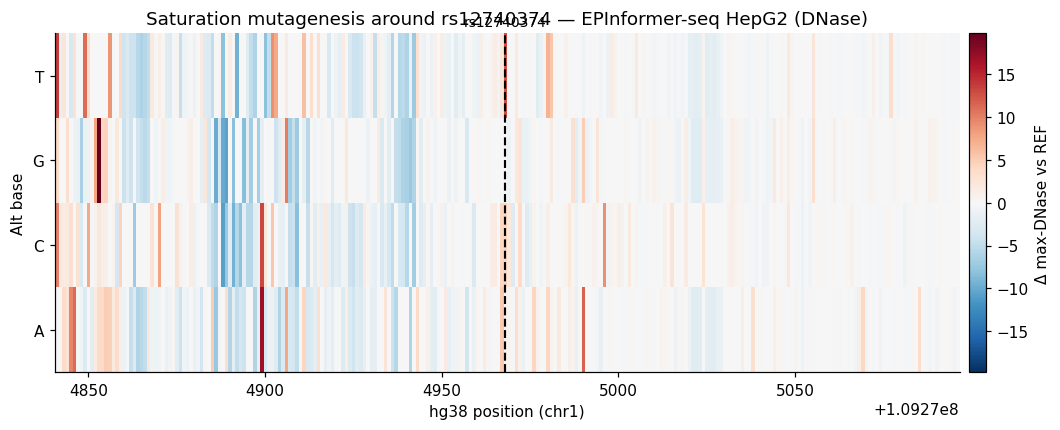

In [14]:
# Heatmap: rows = position (scanned central 256 bp), cols = A/C/G/T. Linear max-DNase units.
fig, ax = plt.subplots(figsize=(11, 4))
vmax = float(np.nanmax(np.abs(ism)))
im = ax.imshow(
    ism.T, aspect='auto', interpolation='nearest',
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    extent=[CENTRAL_GENOME_START - 0.5, CENTRAL_GENOME_START + CENTRAL - 0.5, -0.5, 3.5],
    origin='lower',
)
ax.set_yticks(range(4))
ax.set_yticklabels(bases)
ax.set_xlabel('hg38 position (chr1)')
ax.set_ylabel('Alt base')
ax.set_title('Saturation mutagenesis around rs12740374 — EPInformer-seq HepG2 (DNase)')
ax.axvline(VARIANT_POS, color='black', lw=1.4, ls='--')
ax.text(VARIANT_POS, 3.55, 'rs12740374', ha='center', va='bottom', fontsize=9)
plt.colorbar(im, ax=ax, label='Δ max-DNase vs REF', fraction=0.025, pad=0.01)
plt.show()


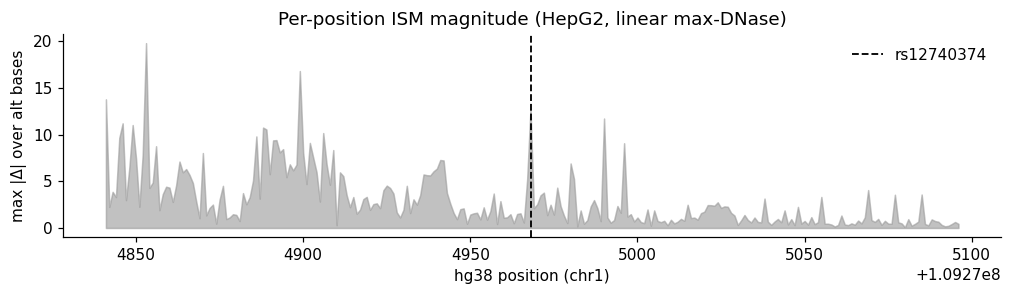

rs12740374 ranks #4 / 256 by max |Δ| over the central 256 bp


In [15]:
# Aggregate to per-position magnitude (over the central 256 bp scanned).
per_pos = np.nanmax(np.abs(ism), axis=1)
# CENTRAL_GENOME_START defined in the ISM cell above.
xs = np.arange(CENTRAL_GENOME_START, CENTRAL_GENOME_START + CENTRAL)

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.fill_between(xs, per_pos, color='#999999', alpha=0.6)
ax.axvline(VARIANT_POS, color='black', lw=1.2, ls='--', label='rs12740374')
ax.set_xlabel('hg38 position (chr1)')
ax.set_ylabel('max |Δ| over alt bases')
ax.set_title('Per-position ISM magnitude (HepG2, linear max-DNase)')
ax.legend(loc='upper right', frameon=False)
plt.show()

# Variant index within the central scanned slice.
variant_idx_in_central = VARIANT_POS - CENTRAL_GENOME_START
variant_rank = int(np.argsort(per_pos)[::-1].tolist().index(variant_idx_in_central))
print(f'rs12740374 ranks #{variant_rank + 1} / {CENTRAL} by max |Δ| over the central {CENTRAL} bp')

> **Interpretation.** The ISM heatmap localises the model's
> sequence-dependence to specific bases. Strong bands cluster around
> TF-footprint-sized windows; if rs12740374's site is among the highest
> per-position magnitudes, the model is sensitive to the exact base at
> the GWAS locus — consistent with the literature showing a C/EBP-α
> motif change drives the regulatory effect.


## 6. Cross-oracle comparison at rs12740374 (HepG2)

Compare the EPInformer-seq max-DNase signal to a complementary chromatin oracle
(ChromBPNet DNase) and — optionally — AlphaGenome's multi-modal output.
AlphaGenome is gated on HuggingFace; that cell is wrapped so the notebook still
completes if you don't have an HF token configured.

Every value is reported in each oracle's native scale (linear max-DNase for
EPInformer-seq, log₂-counts for ChromBPNet, log₂FC for AlphaGenome). The
`linear_fold_change` column (ALT/REF in linear space, per oracle) is the most
directly comparable number across rows.

In [16]:
results = []

# (a) EPInformer-seq (oracle already at HepG2 from §5)
TRACK_HEPG2 = f'{ASSAY}:HepG2'           # Enhancer_DNase:HepG2
oracle.assay_id = TRACK_HEPG2
ve_epi = oracle.predict_variant_effect(
    genomic_region=f'chr1:{REGION_START}-{REGION_END}',
    variant_position=f'chr1:{VARIANT_POS}',
    alleles=['G', 'T'],
    assay_ids=[TRACK_HEPG2],
)
r = float(ve_epi['predictions']['reference'][TRACK_HEPG2].values[0])
a = float(ve_epi['predictions']['alt_1'][TRACK_HEPG2].values[0])
results.append({
    'oracle': 'epinformerseq', 'track': TRACK_HEPG2,
    'ref': r, 'alt': a,
    'native_effect': a - r,            # signed Δ in linear max-DNase
    'linear_fold_change': a / r,        # ALT/REF in the model's native (linear) units
    'effect_pctile': norm.effect_percentile('epinformerseq', TRACK_HEPG2, a - r),
})
print('epinformerseq HepG2:', results[-1])


epinformerseq HepG2: {'oracle': 'epinformerseq', 'track': 'Enhancer_DNase:HepG2', 'ref': 22.47920036315918, 'alt': 35.22125244140625, 'native_effect': 12.74205207824707, 'linear_fold_change': 1.5668374262604923, 'effect_pctile': 1.0}


In [17]:
import numpy as np
# (b) ChromBPNet DNase HepG2 — base-pair-resolution chromatin profile.
try:
    cbp = chorus.create_oracle('chrombpnet', use_environment=True,
                               reference_fasta=str(genome_path))
    cbp.load_pretrained_model(assay='DNASE', cell_type='HepG2', fold=0)
    ve_cbp = cbp.predict_variant_effect(
        genomic_region=f'chr1:{VARIANT_POS - 1057}-{VARIANT_POS + 1057}',
        variant_position=f'chr1:{VARIANT_POS}',
        alleles=['G', 'T'],
        assay_ids=None,
    )
    ref_pred = ve_cbp['predictions']['reference']
    alt_pred = ve_cbp['predictions']['alt_1']
    track_ids = list(ref_pred.keys())
    print('  ChromBPNet returned tracks:', track_ids)
    for tid in track_ids:
        ref_signal = float(ref_pred[tid].values.sum())
        alt_signal = float(alt_pred[tid].values.sum())
        log2fc = float(np.log2((alt_signal + 1e-6) / (ref_signal + 1e-6)))
        try:
            ep = norm.effect_percentile('chrombpnet', tid, log2fc)
        except Exception:
            ep = np.nan
        results.append({
            'oracle': 'chrombpnet', 'track': tid,
            'ref': ref_signal, 'alt': alt_signal,
            'native_effect': log2fc,
            'linear_fold_change': (alt_signal + 1e-6) / (ref_signal + 1e-6),
            'effect_pctile': ep,
        })
        print(f'  chrombpnet {tid}: log2FC={log2fc:+.3f} (fold {results[-1]["linear_fold_change"]:.2f}×)')
except Exception as exc:
    print(f'ChromBPNet skipped: {type(exc).__name__}: {exc}')


2026-06-04 15:29:40,735 - chorus.core.base - INFO - CHORUS_NO_TIMEOUT is set - all timeouts disabled


2026-06-04 15:29:40,735 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-06-04 15:29:44,495 - chorus.core.base - INFO - Using conda environment: chorus-chrombpnet


2026-06-04 15:29:45,253 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/manifest.json "HTTP/1.1 307 Temporary Redirect"


2026-06-04 15:29:45,465 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/lucapinello/chorus-chrombpnet-slim/9fe92856bd189042207a8696f96758c53ea5cdd6/manifest.json "HTTP/1.1 200 OK"


...

2026-06-04 15:29:45,801 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-06-04 15:29:49,918 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


2026-06-04 15:29:58,450 - chorus.analysis.normalization - INFO - Loaded per-track CDFs for 'chrombpnet': 2 tracks, CDFs: effect_cdfs, summary_cdfs, perbin_cdfs


  ChromBPNet returned tracks: ['DNASE:HepG2']
  chrombpnet DNASE:HepG2: log2FC=+1.065 (fold 2.09×)


In [18]:
# (c) AlphaGenome (optional — requires HF auth).
try:
    import os
    if os.environ.get('RUN_ALPHAGENOME') != '1':
        raise RuntimeError('AlphaGenome skipped — set RUN_ALPHAGENOME=1 (and HF auth) to enable')
    ag = chorus.create_oracle('alphagenome', use_environment=True,
                              reference_fasta=str(genome_path))
    ag.load_pretrained_model()

    # rs12740374 acts in HepG2 (hepatocellular — the SORT1 liver-eQTL context),
    # so use the HepG2 cell-line tracks (EFO:0001187). Exact catalog IDs from
    # ag.get_all_assay_ids(): DNase + H3K27ac (enhancer activity) + CAGE (TSS).
    ag_tracks = [
        'DNASE/EFO:0001187 DNase-seq/.',
        'CHIP_HISTONE/EFO:0001187 Histone ChIP-seq H3K27ac/.',
        'CAGE/hCAGE EFO:0001187/+',
    ]
    ve_ag = ag.predict_variant_effect(
        genomic_region=f'chr1:{VARIANT_POS - 100_000}-{VARIANT_POS + 100_000}',
        variant_position=f'chr1:{VARIANT_POS}',
        alleles=['G', 'T'],
        assay_ids=ag_tracks,
    )
    ref_pred = ve_ag['predictions']['reference']
    alt_pred = ve_ag['predictions']['alt_1']
    for tid in ref_pred.keys():
        ref_signal = float(ref_pred[tid].values.sum())
        alt_signal = float(alt_pred[tid].values.sum())
        log2fc = float(np.log2((alt_signal + 1e-6) / (ref_signal + 1e-6)))
        try:
            ep = norm.effect_percentile('alphagenome', tid, log2fc)
        except Exception:
            ep = np.nan
        results.append({
            'oracle': 'alphagenome', 'track': tid,
            'ref': ref_signal, 'alt': alt_signal,
            'native_effect': log2fc,
            'linear_fold_change': (alt_signal + 1e-6) / (ref_signal + 1e-6),
            'effect_pctile': ep,
        })
        print(f'  alphagenome {tid}: log2FC={log2fc:+.3f}')
except Exception as exc:
    print(f'AlphaGenome skipped (this is OK if HF auth is not configured): {type(exc).__name__}: {exc}')

2026-06-04 15:29:58,457 - chorus.core.base - INFO - CHORUS_NO_TIMEOUT is set - all timeouts disabled


2026-06-04 15:29:58,458 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-06-04 15:29:59,851 - chorus.core.base - INFO - Using conda environment: chorus-alphagenome


2026-06-04 15:29:59,852 - chorus.oracles.alphagenome - INFO - Loading AlphaGenome model


2026-06-04 15:32:19,619 - chorus.oracles.alphagenome - INFO - AlphaGenome model loaded successfully in environment!


2026-06-04 15:39:47,147 - chorus.analysis.normalization - INFO - Loaded per-track CDFs for 'alphagenome': 5168 tracks, CDFs: effect_cdfs, summary_cdfs, perbin_cdfs


  alphagenome DNASE/EFO:0001187 DNase-seq/.: log2FC=+0.040
  alphagenome CHIP_HISTONE/EFO:0001187 Histone ChIP-seq H3K27ac/.: log2FC=+0.069
  alphagenome CAGE/hCAGE EFO:0001187/+: log2FC=+0.014


In [19]:
xo = pd.DataFrame(results)
xo


,oracle,track,ref,alt,native_effect,linear_fold_change,effect_pctile
0,epinformerseq,Enhancer_DNase:HepG2,2.247920e+01,3.522125e+01,12.742052,1.566837,1.0
1,chrombpnet,DNASE:HepG2,4.578026e+02,9.579306e+02,1.065195,2.092453,NaN
2,alphagenome,DNASE/EFO:0001187 DNase-seq/.,6.539335e+04,6.722060e+04,0.039760,1.027943,1.0
3,alphagenome,CHIP_HISTONE/EFO:0001187 Histone ChIP-seq H3K2...,1.163125e+06,1.220373e+06,0.069316,1.049219,1.0
4,alphagenome,CAGE/hCAGE EFO:0001187/+,6.969803e+04,7.036182e+04,0.013675,1.009524,1.0


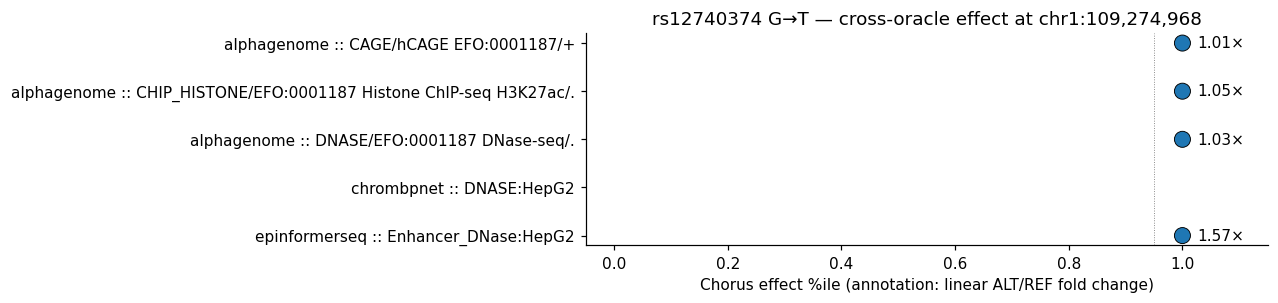

In [20]:
if len(xo) > 1:
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45 * len(xo))))
    ys = np.arange(len(xo))
    ax.scatter(xo['effect_pctile'], ys, s=110,
               c=['#1f77b4' if e > 0 else '#d62728' for e in xo['native_effect']],
               edgecolor='k', linewidth=0.6, zorder=3)
    for i, row in xo.reset_index(drop=True).iterrows():
        ax.annotate(f"{row['linear_fold_change']:.2f}×",
                    (row['effect_pctile'], i),
                    xytext=(10, 0), textcoords='offset points', va='center')
    ax.set_yticks(ys)
    ax.set_yticklabels(xo['oracle'] + ' :: ' + xo['track'])
    ax.set_xlabel('Chorus effect %ile (annotation: linear ALT/REF fold change)')
    ax.set_xlim(-0.05, 1.15)
    ax.axvline(0.95, color='gray', lw=0.6, ls=':')
    ax.set_title('rs12740374 G→T — cross-oracle effect at chr1:109,274,968')
    plt.show()
else:
    print('Only one oracle returned results — skipping cross-oracle plot.')


## 7. Summary

What this notebook verified end-to-end:

| Check | API surface |
|---|---|
| Instantiate via `create_oracle('epinformerseq', use_environment=True)` | factory wiring in `chorus/__init__.py` |
| Cell switching via `load_pretrained_model(cell_type=...)` | per-cell ckpt swap, no FiLM |
| Scalar `predict()` on genomic coords and raw sequence | `_predict` aggregates the chosen channel over the central 256 bp of the 1024-bp crop |
| Variant effect for any of the 3 assays | `predict_variant_effect` (linear ALT−REF) |
| Percentile lookup against the per-track CDF | `PerTrackNormalizer('epinformerseq')` (33 tracks: 3 assays × 11 cells) |
| Saturation mutagenesis at base resolution | direct `predict(seq)` loop over the scanned central window, batched via `run_code_in_environment` |
| Cross-oracle comparability at a shared locus | ChromBPNet (+ optional AlphaGenome) |

**Architecture recap.** EPInformer-seq is `PerCellProfileNetWide`: a **2114-bp**
input run through a dilated body, with the central **1024 bp** cropped for the
profile + count heads (ChromBPNet-style valid geometry). It has **two channels**
— ch0 = DNase (5′ cut-sites), ch1 = H3K27ac (the active-enhancer histone mark) —
paired with a per-cell frozen 2-channel `BiasNet`.

**Output units recap.** The scalar is the linear peak signal over the central
256 bp of the 1024-bp output (not log₂), for the chosen assay: `Enhancer_DNase`
(max DNase), `Enhancer_H3K27ac` (max H3K27ac), or `Enhancer_H3K27ac_DNase`
(composite `sqrt(D·H)`). Both the WT value and the variant effect are in this
linear scale, matching the activity %ile CDF.

**When to reach for EPInformer-seq**
- A fast (<1 ms / forward pass) per-cell DNase **and** H3K27ac readout in one of
  the 11 Roadmap cell lines, with 2114 bp of context around the variant.
- DNase cut-site resolution sharpens variant effects at TF-motif loci (e.g.
  rs12740374) relative to read-coverage models.

**Limitations**
- Two marks only (DNase + H3K27ac); ~2114-bp context — captures local TF
  footprints and short-range enhancer structure, not long-range
  insulator/promoter contacts (use AlphaGenome / Borzoi for that).
- One scalar per call — ISM gives per-position resolution via 256 × 3 forward
  passes over the central scanned slice.
- 11 fixed Roadmap cells — for additional cell types retrain a checkpoint via
  the upstream [EPInformer training scripts](https://github.com/pinellolab/EPInformer).